In [2]:
import pandas as pd
import glob
from scipy import signal
import matplotlib.pyplot as plt
import numpy as np
from scipy import stats


In [3]:
###
# All variables releated data are located here to make an order
###
PATH="C:\\Users\\emirc\\Desktop\\AAR\\data\\csv\\datas/*" #Refer the path having the csv files
ANIMALS_USED=[1]   #Animal numbers to study on 
COLUMNS_REMOVE=['Mx','My','Mz','Gx','Gy','Gz',] #Columns to delete such as Gx Gy Gz
ACTIVITIES_MERGE={'running-natural': 'running',
                 'running-rider': 'running',
                  'trotting-natural': 'trotting',    #Having nearly the same meaning
                  'trotting-rider': 'trotting',} 
TIME_PERIODS = 500
STEP_DISTANCE = 100
filePaths = sorted(glob.glob(PATH))


In [4]:
def createDataFrame(filePaths):
    dataFrame=pd.DataFrame()
    for fileName in filePaths:
        csv=pd.read_csv(fileName,low_memory=False)
        dataFrame=dataFrame.append(csv)

    #Removing needless horses
    dataFrame=dataFrame[dataFrame['subject'].isin(ANIMALS_USED)]
    
    #Removing columns
    dataFrame.drop(COLUMNS_REMOVE,axis=1,inplace=True)
    
    #Merging activities
    for key in ACTIVITIES_MERGE:
        dataFrame['label'] = dataFrame['label'].replace(to_replace=key, value=ACTIVITIES_MERGE.get(key))
       
    #deleting unlabeled data
    dataFrame=dataFrame[~(dataFrame['label'].isin(['unknown']))]
    
    #removing nulls
    dataFrame=dataFrame.dropna(axis=0, how='any')
    return dataFrame

In [5]:
def lowBufferFiltering(dataFrame):
    sos = signal.butter(N=3, Wn=30, btype='lowpass', fs=100, output='sos')
    dataFrame['Ax'] = signal.sosfilt(sos, dataFrame['Ax'])
    dataFrame['Ay'] = signal.sosfilt(sos, dataFrame['Ay'])
    dataFrame['Az'] = signal.sosfilt(sos, dataFrame['Az'])
    return dataFrame
    

In [6]:
def window(dataFrame,labelName):
    windows = []
    labels = []
    for i in range(0, len(dataFrame)-TIME_PERIODS, STEP_DISTANCE):
        axs = dataFrame['Ax'].values[i: i + TIME_PERIODS]
        ays = dataFrame['Ay'].values[i: i + TIME_PERIODS]
        azs = dataFrame['Az'].values[i: i + TIME_PERIODS]
        
        # Retrieve the most often used label in this segment
        label = stats.mode(dataFrame[labelName][i: i + TIME_PERIODS])[0][0]
        windows.append([axs, ays, azs])
        labels.append(label)
    reshaped_windows = np.asarray(windows, dtype= np.float32).reshape(-1, TIME_PERIODS, 6)
    labels = np.asarray(labels)
    return reshaped_windows, labels

In [7]:
def inputShape(dataFrame):
    dataFrame = dataFrame.reshape(dataFrame.shape[0], input_shape)
    return dataFrame

In [11]:
dataFrame=createDataFrame(filePaths)
#not to lose labels
labels=dataFrame.columns

#filtering
dataFrame=lowBufferFiltering(dataFrame)

#Converting dataframe from numpy array
dataFrame=pd.DataFrame(dataFrame,columns=labels)

#Windowing
dataFrame=window(dataFrame,'Ax')

In [12]:
with open("C:\\Users\\emirc\\Desktop\\AAR\\output", 'a') as f:
    dataFrameAsString = dataFrame.to_string()
    f.write(dataFrameAsString)

    

AttributeError: 'numpy.ndarray' object has no attribute 'to_string'

TypeError: tuple indices must be integers or slices, not str

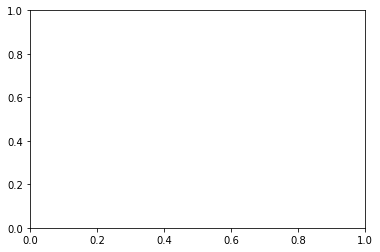

In [10]:
fig, ax = plt.subplots()
dataFrame['Ax'].value_counts().plot(ax=ax, kind='bar')

In [69]:
plt.show()